<a href="https://colab.research.google.com/github/guilhermelaviola/DataScienceApplicationsInComputerVision/blob/main/Class15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Integrated Projects & Real-World Applications**
Integrated computer vision projects represent a synergy of sophisticated hardware and software designed to transform visual data into actionable, real-time insights across various critical sectors. In healthcare, convolutional neural networks (CNNs) enable rapid, accurate diagnoses by identifying subtle anomalies in medical imaging, while the security industry utilizes optimized algorithms like YOLO to monitor environments and detect suspicious behavior instantly. The automotive sector relies on these technologies, alongside techniques like SLAM (Simultaneous Localization and Mapping), to facilitate autonomous navigation and driver assistance by integrating data from cameras, radar, and LIDAR. Beyond theoretical application, the practical development of these systems—as demonstrated by implementing a YOLO pipeline in environments like Google Colab—requires careful orchestration of image pre-processing, neural network inference, and post-processing techniques like Non-Maxima Suppression to ensure precision and reliability in solving real-world industrial and social challenges.

In [14]:
# Instaling the necessary dependencies:
!pip install opencv-python-headless

In [15]:
# Importing all the necessary libraries and resouces:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from google.colab.patches import cv2_imshow

In [16]:
# Downloading the pretrained version of YOLO:
yolo_config = 'https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg'
yolo_weights = 'https://pjreddie.com/media/files/yolov3.weights'
yolo_classes = 'https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names'

# Downloading the YOLO files:
!wget $yolo_config -O yolov3.cfg
!wget $yolo_weights -O yolov3.weights
!wget $yolo_classes -O coco.names

# Loading the pretrained YOLO network:
net = cv2.dnn.readNet('yolov3.weights', 'yolov3.cfg')
with open('coco.names', 'r') as f:
  classes = [line.strip() for line in f.readlines()]

layer_names = net.getLayerNames()
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]

--2026-03-22 00:53:40--  https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8342 (8.1K) [text/plain]
Saving to: ‘yolov3.cfg’

yolov3.cfg          100%[===================>]   8.15K  --.-KB/s    in 0s      

2026-03-22 00:53:40 (35.2 MB/s) - ‘yolov3.cfg’ saved [8342/8342]

--2026-03-22 00:53:40--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 172.67.185.199, 104.21.88.156, 2606:4700:3030::ac43:b9c7, ...
Connecting to pjreddie.com (pjreddie.com)|172.67.185.199|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://data.pjreddie.com/files/yolov3.weights [following]
--2026-03-22 00:53:40--  https://data.pjre

In [17]:
# Function to draw boxes around detected objects:
def draw_boxes(img, outs):
  height, width, channels = img.shape
  boxes = []
  confidences = []
  class_ids = []

  for out in outs:
    for detection in out:
      scores = detection[5:]
      class_id = np.argmax(scores)
      confidence = scores[class_id]
      if confidence > 0.5:
        center_x = int(detection[0] * width)
        center_y = int(detection[1] * height)
        w = int(detection[2] * width)
        h = int(detection[3] * height)
        x = int(center_x - w / 2)
        y = int(center_y - h / 2)
        boxes.append([x, y, w, h])
        confidences.append(float(confidence))
        class_ids.append(class_id)

  indexes = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)

  for i in indexes:
    box = boxes[i]
    x, y, W, h = box[0], box[1], box[2], box[3]
    label = str(classes[class_ids[i]])
    cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)
    cv2.putText(img, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

In [18]:
# Allowing the user to upload an image:
uploaded = files.upload()

# Loading the image:
image_path = list(uploaded.keys())[0]
image = cv2.imread(image_path)

Saving italian-restaurant.webp to italian-restaurant (2).webp


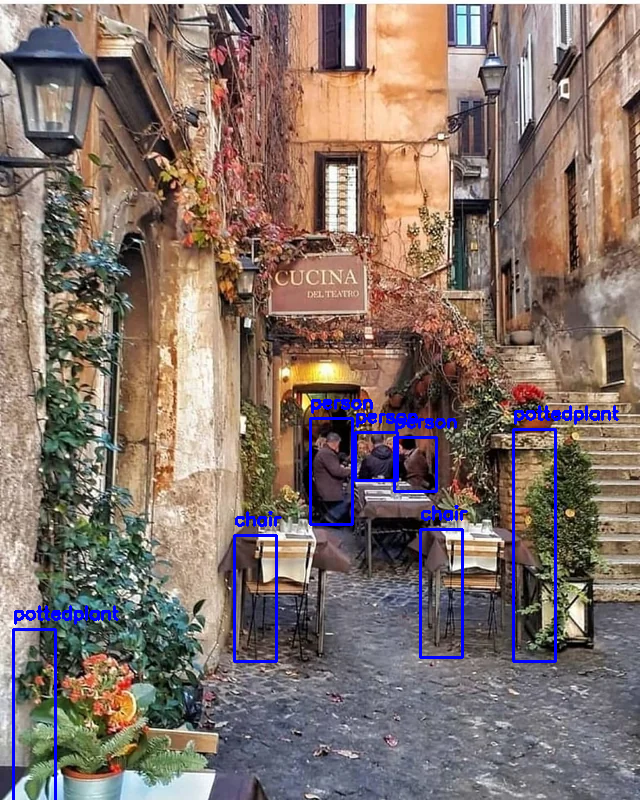

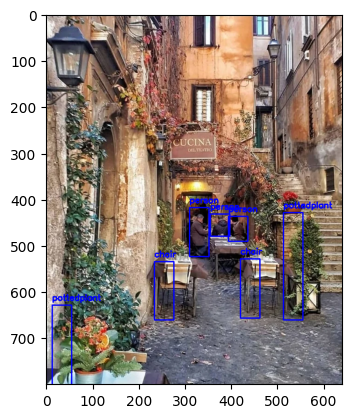

In [19]:
# Checking if the image was loaded correctly:
if image is None:
  raise ValueError(f'The image could not be loaded {image_path}')

# Detecting the objects:
blob = cv2.dnn.blobFromImage(image, 0.00392, (416, 416), (0, 0, 0), True, crop=False)
net.setInput(blob)
outs = net.forward(output_layers)

# Drawing the detection boxes on the image:
draw_boxes(image, outs)

# Displaying the resulting image using cv2_imshow (compatible with Google Colab):
cv2_imshow(image)

# Displaying the resulting image using matplotlib:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()